# Load Data

In [1]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer


df_train_clean = pd.read_csv('data_output/1_data_cleaned_train.csv')
df_test_clean = pd.read_csv('data_output/1_data_cleaned_test.csv')

print(" Train and Test data downloaded successfully!")


target_col = 'Khoảng giá' 

X_train = df_train_clean.drop(columns=[target_col])
y_train = df_train_clean[target_col]

X_test = df_test_clean.drop(columns=[target_col])
y_test = df_test_clean[target_col]

print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")

 Train and Test data downloaded successfully!
X_train size: (4645, 25)
X_test size: (1164, 25)


# 1. Encode Categorical Variables: 'Pháp lí', 'Nội thất'

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25780\1436922763.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25780\1436922763.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25780\1436922763.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25780\1436922763.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

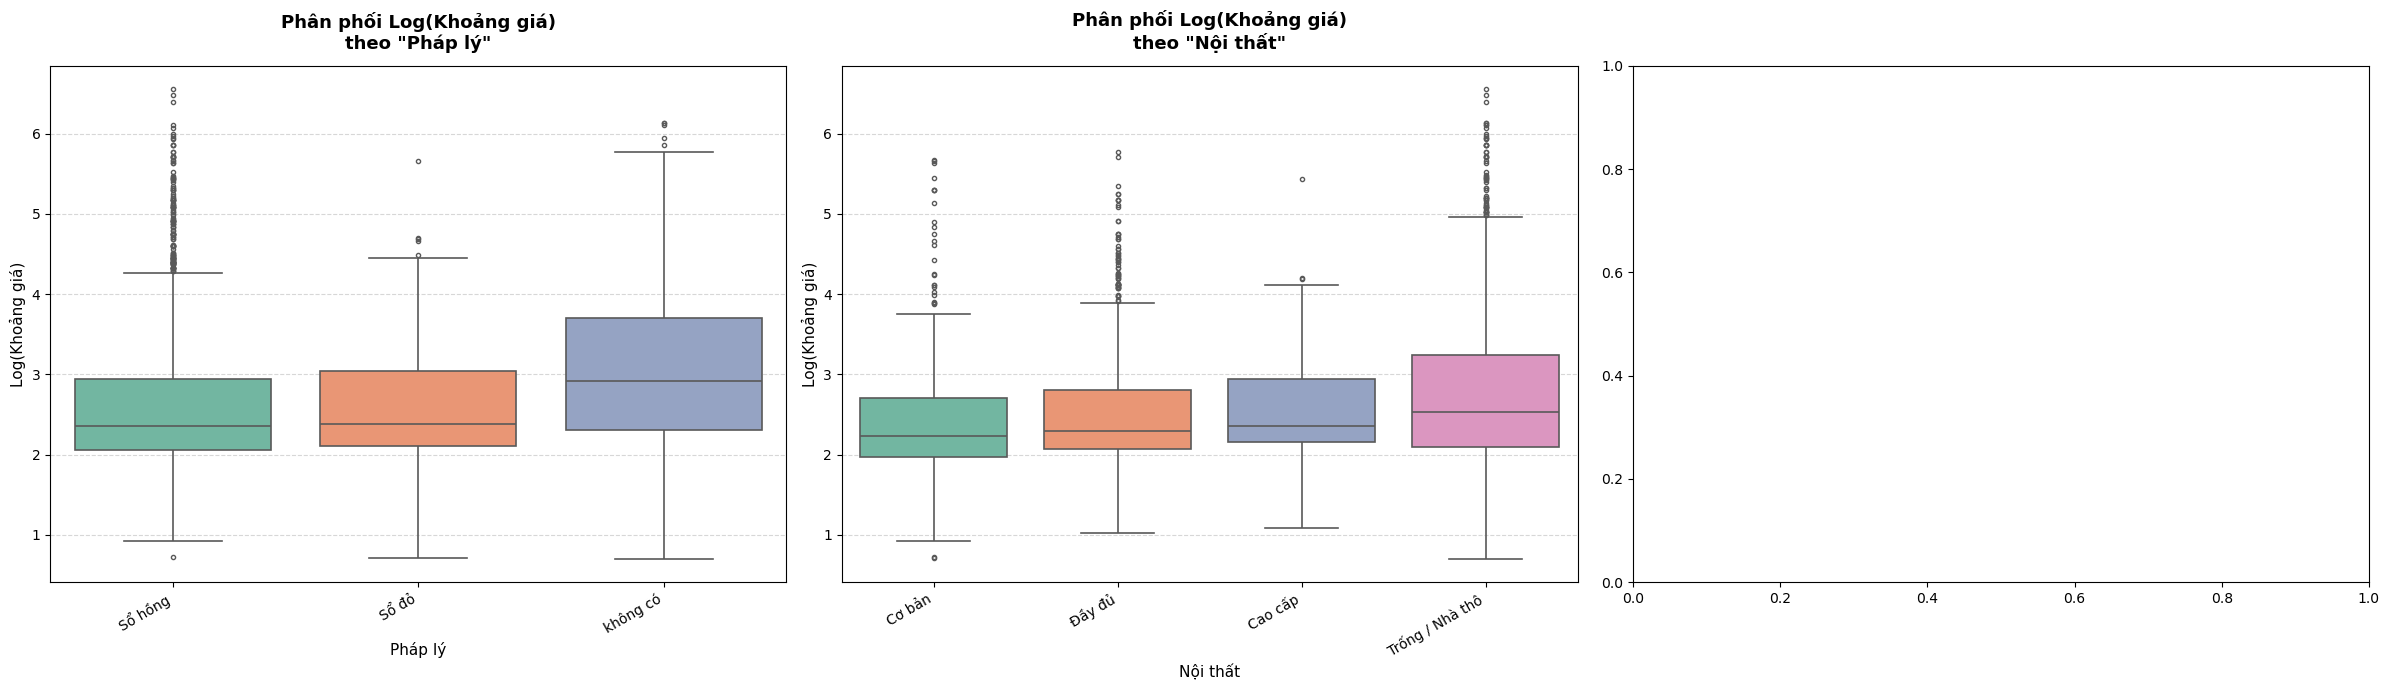

In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.concat([X_train, y_train], axis=1)

target_col = y_train.name if isinstance(y_train, pd.Series) else y_train.columns[0]

log_target_col = f'Log_{target_col}'
train_data[log_target_col] = np.log1p(train_data[target_col])

cat_cols = ['Pháp lý', 'Nội thất', 'Loại đường vào']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for i, col in enumerate(cat_cols):
    if col in train_data.columns:
        group_order = train_data.groupby(col)[log_target_col].median().sort_values().index
        
        sns.boxplot(
            x=col, 
            y=log_target_col,  
            data=train_data, 
            ax=axes[i], 
            order=group_order,
            palette='Set2',
            fliersize=3,       
            linewidth=1.2     
        )
        
        axes[i].set_title(f'Phân phối Log({target_col})\ntheo "{col}"', fontsize=13, fontweight='bold', pad=12)
        axes[i].set_xlabel(col, fontsize=11)
        axes[i].set_ylabel(f'Log({target_col})', fontsize=11)
        axes[i].grid(axis='y', linestyle='--', alpha=0.5)
        
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

phap_ly_order = ['không có', 'Sổ đỏ', 'Sổ hồng']

noi_that_order = ['Trống / Nhà thô', 'Cơ bản', 'Đầy đủ', 'Cao cấp']

orde = OrdinalEncoder(
    categories=[phap_ly_order, noi_that_order], 
    handle_unknown='use_encoded_value', 
    unknown_value=-1
)

ord_cols = ['Pháp lý', 'Nội thất']

X_train[ord_cols] = orde.fit_transform(X_train[ord_cols])

X_test[ord_cols] = orde.transform(X_test[ord_cols])

print(" Successfully applied Ordinal Encoding to Pháp lý and Nội thất!")
print(f"Coded Legal Order: {phap_ly_order} -> [0, 1, 2]")
print(f"Coded Interior Order: {noi_that_order} -> [0, 1, 2, 3]")

 Successfully applied Ordinal Encoding to Pháp lý and Nội thất!
Coded Legal Order: ['không có', 'Sổ đỏ', 'Sổ hồng'] -> [0, 1, 2]
Coded Interior Order: ['Trống / Nhà thô', 'Cơ bản', 'Đầy đủ', 'Cao cấp'] -> [0, 1, 2, 3]


# 2. Encode Address Variables

In [4]:
import pandas as pd
from category_encoders import TargetEncoder

cols_quan = ['Quan_Huyen']
te_quan = TargetEncoder(cols=cols_quan, smoothing=10.0, min_samples_leaf=50)

X_train[cols_quan] = te_quan.fit_transform(X_train[cols_quan], y_train)
X_test[cols_quan] = te_quan.transform(X_test[cols_quan])


cols_phuong_duong = ['Phuong_Xa', 'Duong']
te_phuong_duong = TargetEncoder(cols=cols_phuong_duong, smoothing=10.0, min_samples_leaf=5)

X_train[cols_phuong_duong] = te_phuong_duong.fit_transform(X_train[cols_phuong_duong], y_train)
X_test[cols_phuong_duong] = te_phuong_duong.transform(X_test[cols_phuong_duong])


print(" Target Encoding applied successfully!")
print("  - Column 'Quận': min_samples_leaf = 50")
print("  - Columns 'Phường/Xã/Thị Trấn' & 'Đường_Từ_Địa_Chỉ': min_samples_leaf = 5")

 Target Encoding applied successfully!
  - Column 'Quận': min_samples_leaf = 50
  - Columns 'Phường/Xã/Thị Trấn' & 'Đường_Từ_Địa_Chỉ': min_samples_leaf = 5


# 3. Scale Numerical Features

This dataset is aimed at predicting house prices, which is a regression problem. Normalization methods will target building datasets suitable for linear regression models that assume data follows a normal distribution.

Statistics of numerical feature distributions.

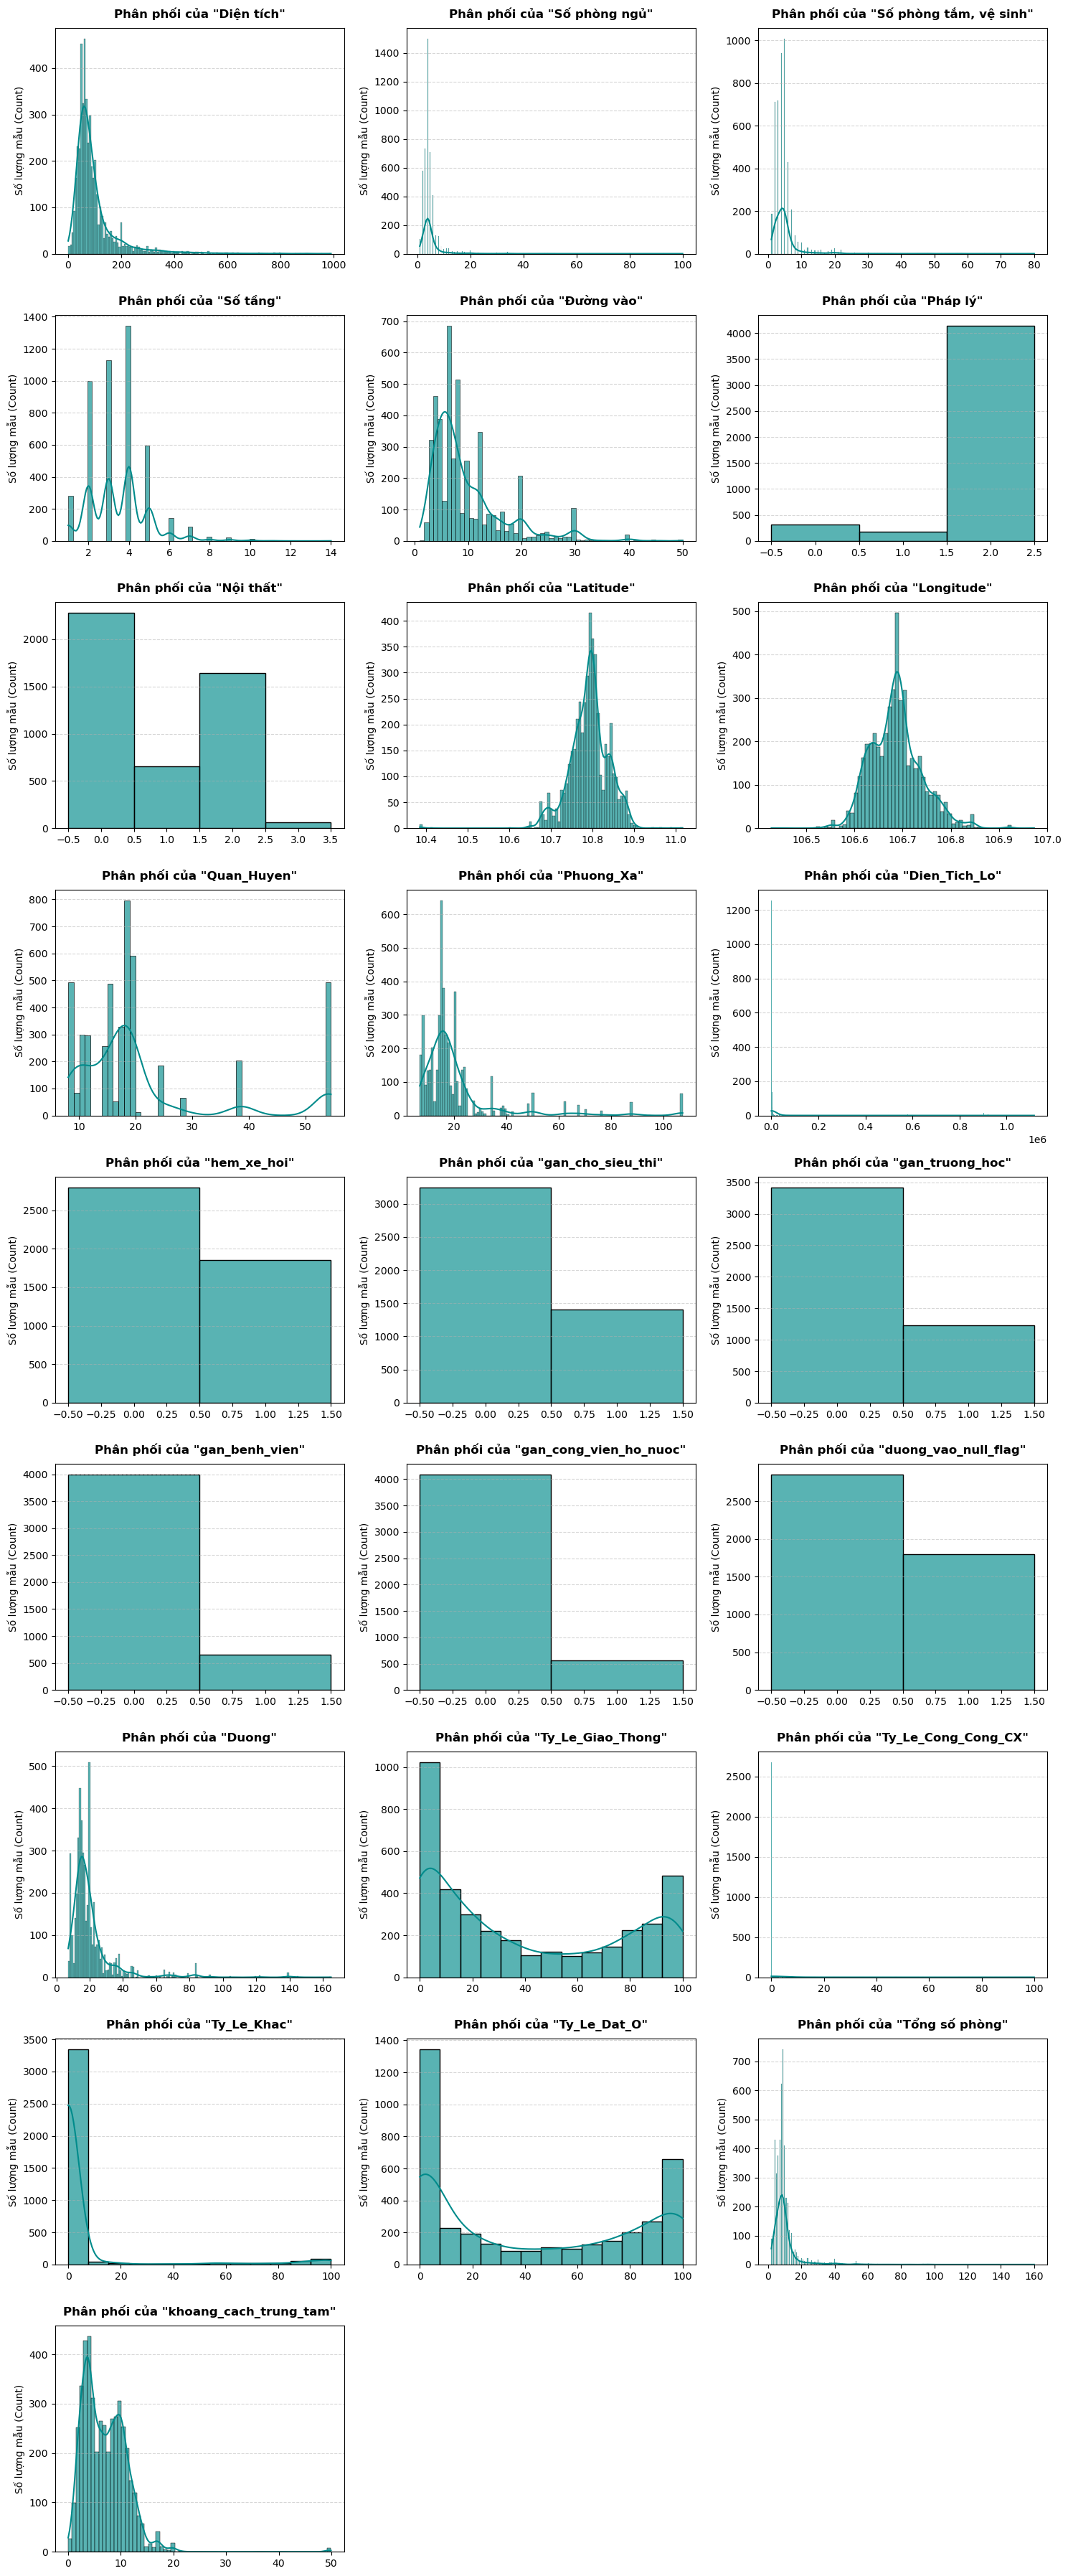

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = list(X_train.select_dtypes(include=[np.number]).columns)
num_features = len(numeric_features)

cols_per_row = 3
num_rows = math.ceil(num_features / cols_per_row)

fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(cols_per_row * 5, num_rows * 4))

if num_features > 1:
    axes = axes.flatten()
else:
    axes = [axes] 

for i, col in enumerate(numeric_features):
    ax = axes[i]
    
    is_discrete = X_train[col].nunique() <= 5
    
    sns.histplot(
        data=X_train,
        x=col,
        kde=not is_discrete, 
        discrete=is_discrete, 
        ax=ax,
        color='darkcyan',     
        edgecolor='black',
        alpha=0.65
    )
    
    ax.set_title(f'Phân phối của "{col}"', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')  
    ax.set_ylabel('Số lượng mẫu (Count)', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3.1 Normalize 'Area', 'Entrance Width' and 'Total Rooms'

These two features have heavily right-skewed distributions. Use logarithmic transformation to normalize the data and then apply StandardScaler or RobustScaler.

### Method 1: Log Transform followed by StandardScaler

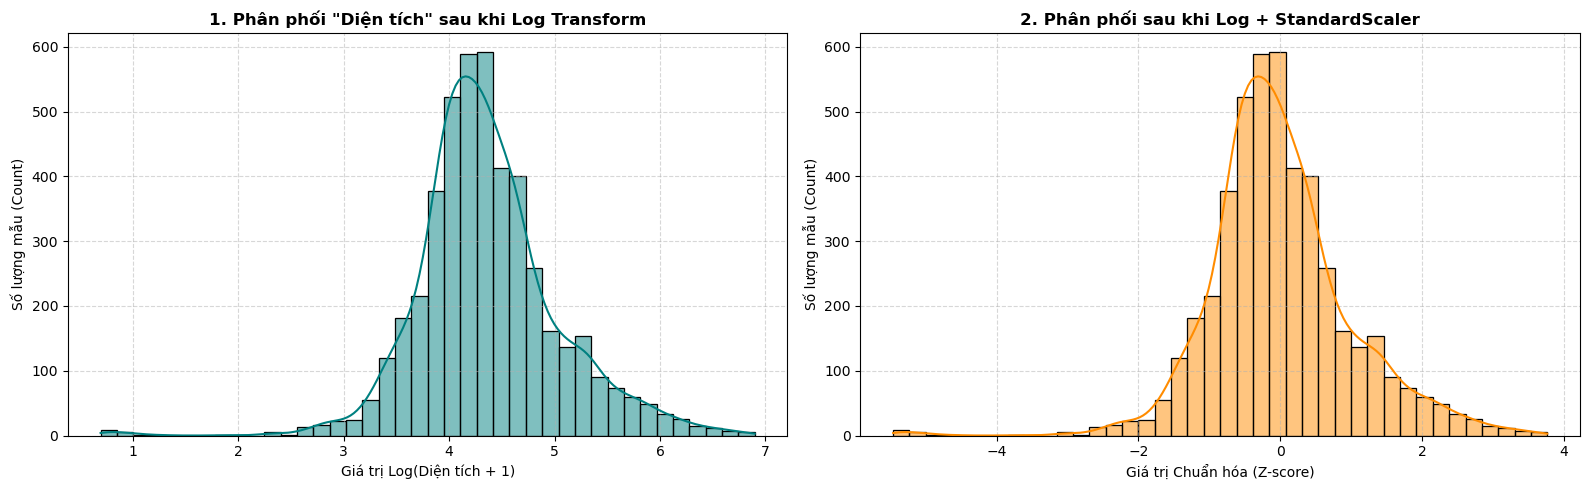

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

dien_tich_test = X_train['Diện tích'].copy()

dien_tich_log = np.log1p(dien_tich_test)

scaler_test = StandardScaler()
dien_tich_scaled = scaler_test.fit_transform(dien_tich_log.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(dien_tich_log, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. Phân phối "Diện tích" sau khi Log Transform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị Log(Diện tích + 1)')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(dien_tich_scaled, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('2. Phân phối sau khi Log + StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Z-score)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Method 2: RobustScaler

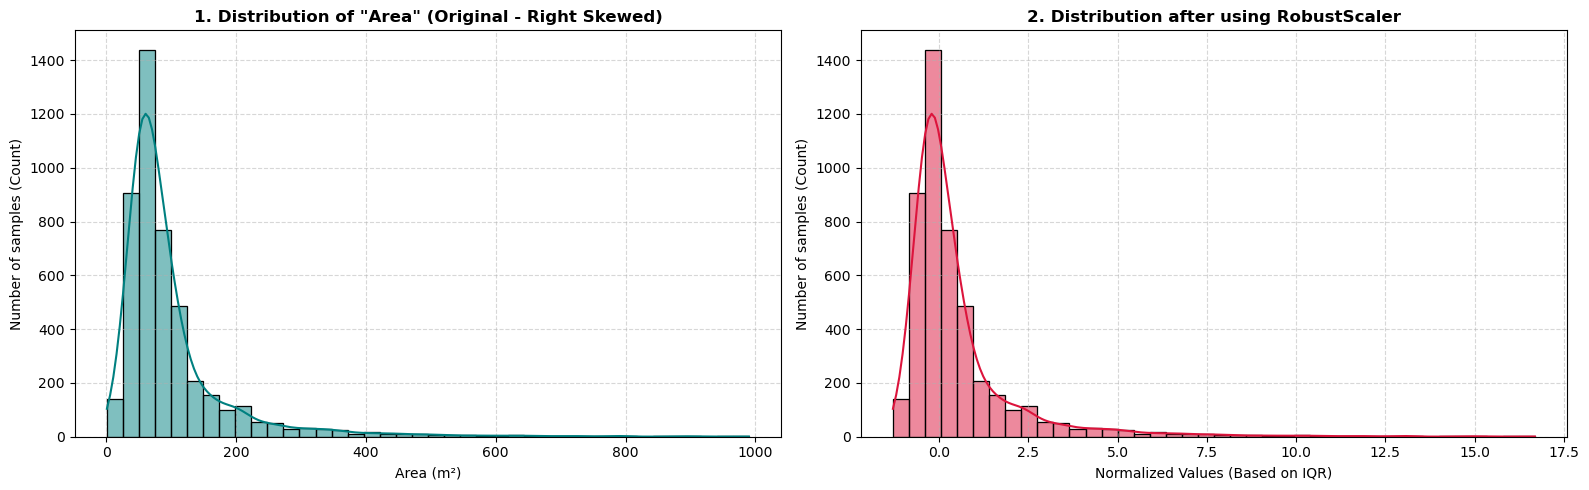

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

dien_tich_test = X_train['Diện tích'].copy()

scaler_robust_test = RobustScaler()
dien_tich_robust = scaler_robust_test.fit_transform(dien_tich_test.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(dien_tich_test, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. Distribution of "Area" (Original - Right Skewed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Area (m²)')
axes[0].set_ylabel('Number of samples (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(dien_tich_robust, kde=True, ax=axes[1], color='crimson', bins=40)
axes[1].set_title('2. Distribution after using RobustScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Normalized Values (Based on IQR)')
axes[1].set_ylabel('Number of samples (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The distribution remains right-skewed after RobustScaler transformation. Using logarithmic transformation followed by StandardScaler will bring the distribution to a form more favorable for training regression models.

### Choose a Method

 Applying Method 1: Logarithm + StandardScaler...
 Finished applying Log + StandardScaler to both X_train and X_test!


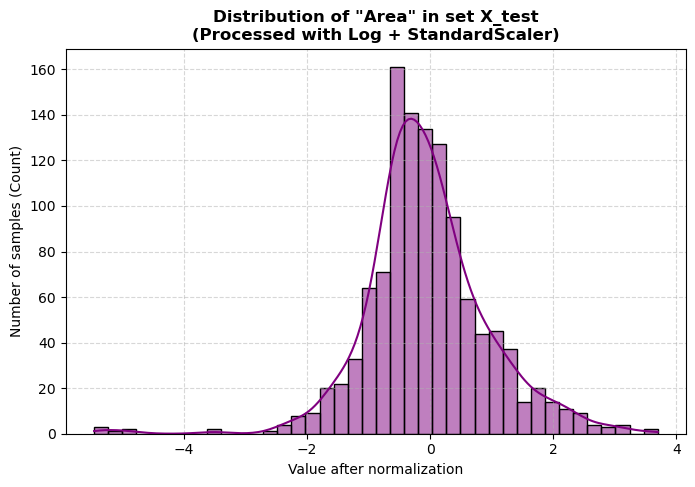

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler


PHUONG_PHAP = 1 

if PHUONG_PHAP == 1:
    print(" Applying Method 1: Logarithm + StandardScaler...")
    X_train['Diện tích'] = np.log1p(X_train['Diện tích'])
    X_test['Diện tích'] = np.log1p(X_test['Diện tích'])
    
    scaler = StandardScaler()
    X_train['Diện tích'] = scaler.fit_transform(X_train[['Diện tích']])
    X_test['Diện tích'] = scaler.transform(X_test[['Diện tích']])
    method_name = "Log + StandardScaler"

elif PHUONG_PHAP == 2:
    print(" Applying Method 2: RobustScaler...")
    scaler = RobustScaler()
    X_train['Diện tích'] = scaler.fit_transform(X_train[['Diện tích']])
    X_test['Diện tích'] = scaler.transform(X_test[['Diện tích']])
    method_name = "RobustScaler"

else:
    print("Invalid selection. Please select 1 or 2.")

if PHUONG_PHAP in [1, 2]:
    print(f" Finished applying {method_name} to both X_train and X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Diện tích'], kde=True, color='purple', bins=40)
    plt.title(f'Distribution of "Area" in set X_test\n(Processed with {method_name})', fontsize=12, fontweight='bold')
    plt.xlabel('Value after normalization')
    plt.ylabel('Number of samples (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 3.2 Handle 'Entrance Width'

### Method 1: Log Transform followed by StandardScaler

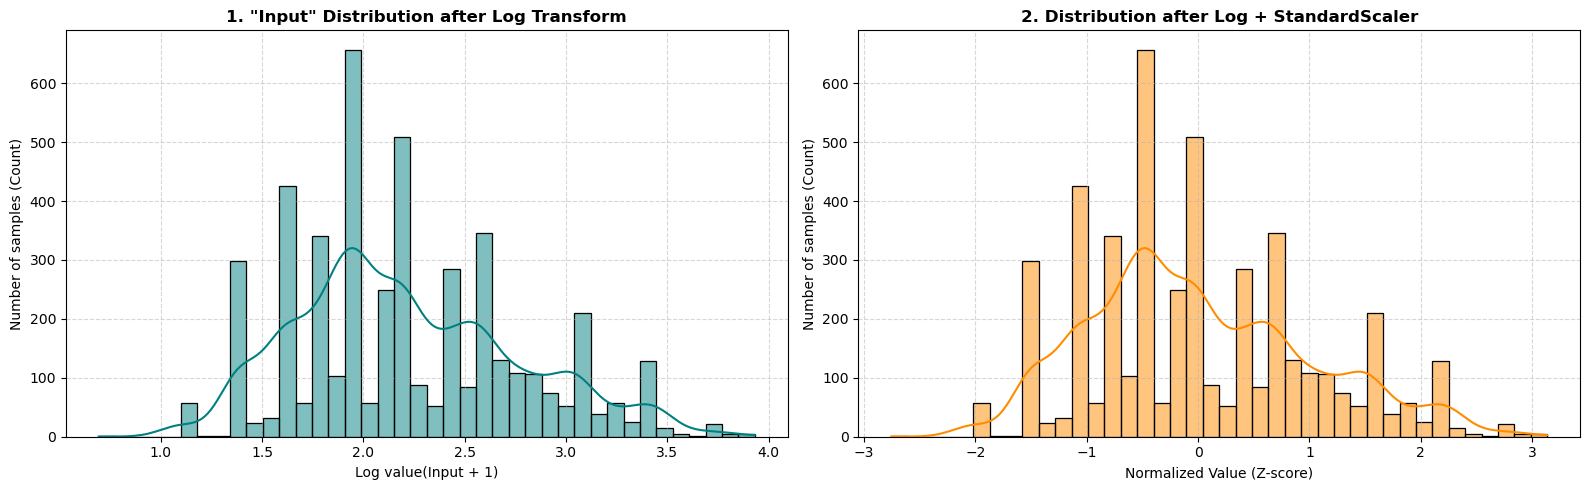

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

dien_tich_test = X_train['Đường vào'].copy()

dien_tich_log = np.log1p(dien_tich_test)
scaler_test = StandardScaler()
dien_tich_scaled = scaler_test.fit_transform(dien_tich_log.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(dien_tich_log, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. "Input" Distribution after Log Transform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log value(Input + 1)')
axes[0].set_ylabel('Number of samples (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(dien_tich_scaled, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('2. Distribution after Log + StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Normalized Value (Z-score)')
axes[1].set_ylabel('Number of samples (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Method 2: RobustScaler

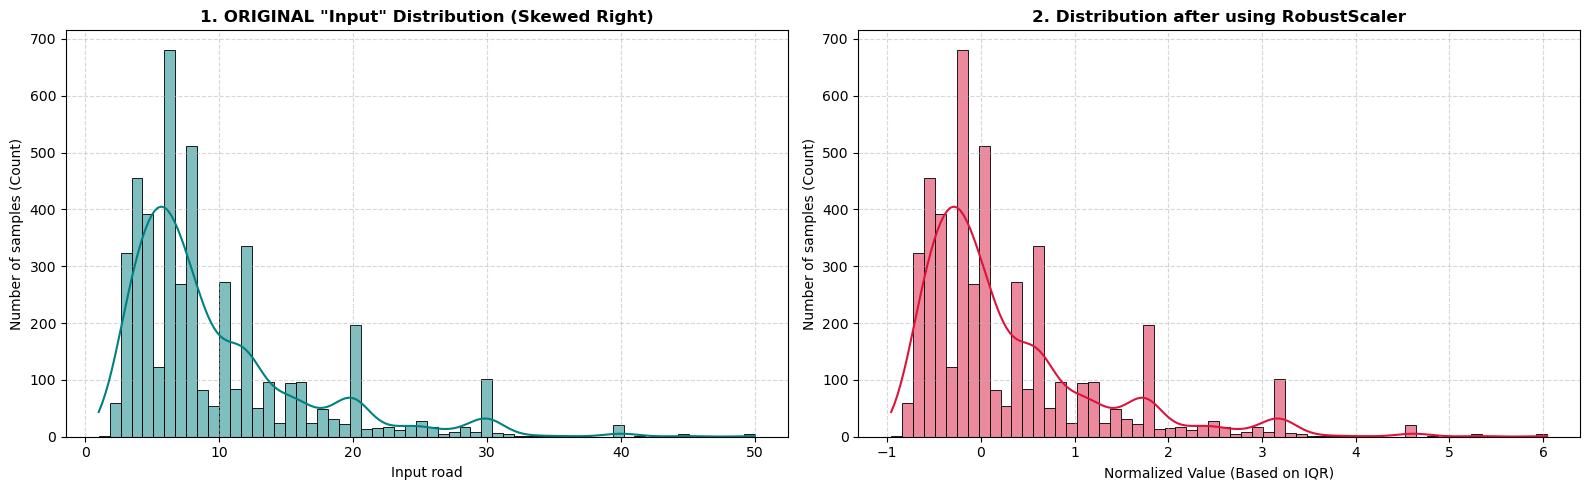

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

duong_vao_test = X_train['Đường vào'].copy()

scaler_robust_test = RobustScaler()
duong_vao_robust = scaler_robust_test.fit_transform(duong_vao_test.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(duong_vao_test, kde=True, ax=axes[0], color='teal', bins=60)
axes[0].set_title('1. ORIGINAL "Input" Distribution (Skewed Right)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Input road')
axes[0].set_ylabel('Number of samples (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(duong_vao_robust, kde=True, ax=axes[1], color='crimson', bins=60)
axes[1].set_title('2. Distribution after using RobustScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Normalized Value (Based on IQR)')
axes[1].set_ylabel('Number of samples (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Choose a Method

Applying Method 1: Logarithm + StandardScaler...
✅ Finished applying Log + StandardScaler to both X_train and X_test!


c:\Users\ADMIN\anaconda3\envs\tu_duy_tinh_toan\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


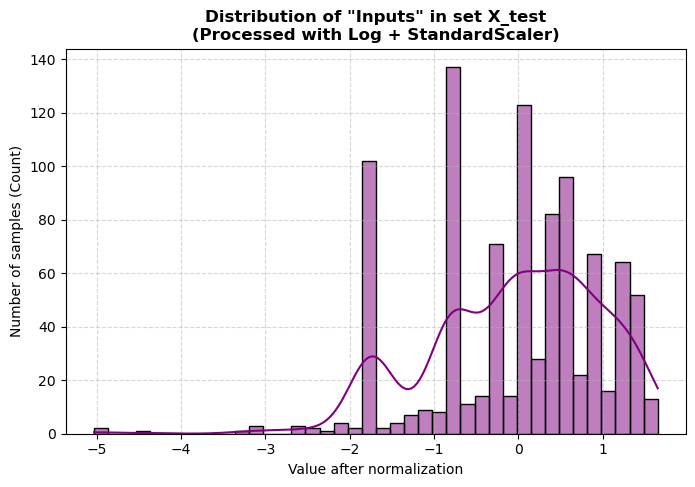

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler



if PHUONG_PHAP == 1:
    print("Applying Method 1: Logarithm + StandardScaler...")
    X_train['Đường vào'] = np.log1p(X_train['Đường vào'])
    X_test['Đường vào'] = np.log1p(X_test['Đường vào'])
    
    scaler = StandardScaler()
    X_train['Đường vào'] = scaler.fit_transform(X_train[['Đường vào']])
    X_test['Đường vào'] = scaler.transform(X_test[['Đường vào']])
    method_name = "Log + StandardScaler"

elif PHUONG_PHAP == 2:
    print(" Applying Method 2: RobustScaler...")
    scaler = RobustScaler()
    X_train['Đường vào'] = scaler.fit_transform(X_train[['Đường vào']])
    X_test['Đường vào'] = scaler.transform(X_test[['Đường vào']])
    method_name = "RobustScaler"

else:
    print(" Invalid selection. Please select 1 or 2.")

if PHUONG_PHAP in [1, 2]:
    print(f"✅ Finished applying {method_name} to both X_train and X_test!")
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Đường vào'], kde=True, color='purple', bins=40)
    plt.title(f'Distribution of "Inputs" in set X_test\n(Processed with {method_name})', fontsize=12, fontweight='bold')
    plt.xlabel('Value after normalization')
    plt.ylabel('Number of samples (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 3.3 Normalize 'Number of Floors'

### Method 1: Use Log and Standardization

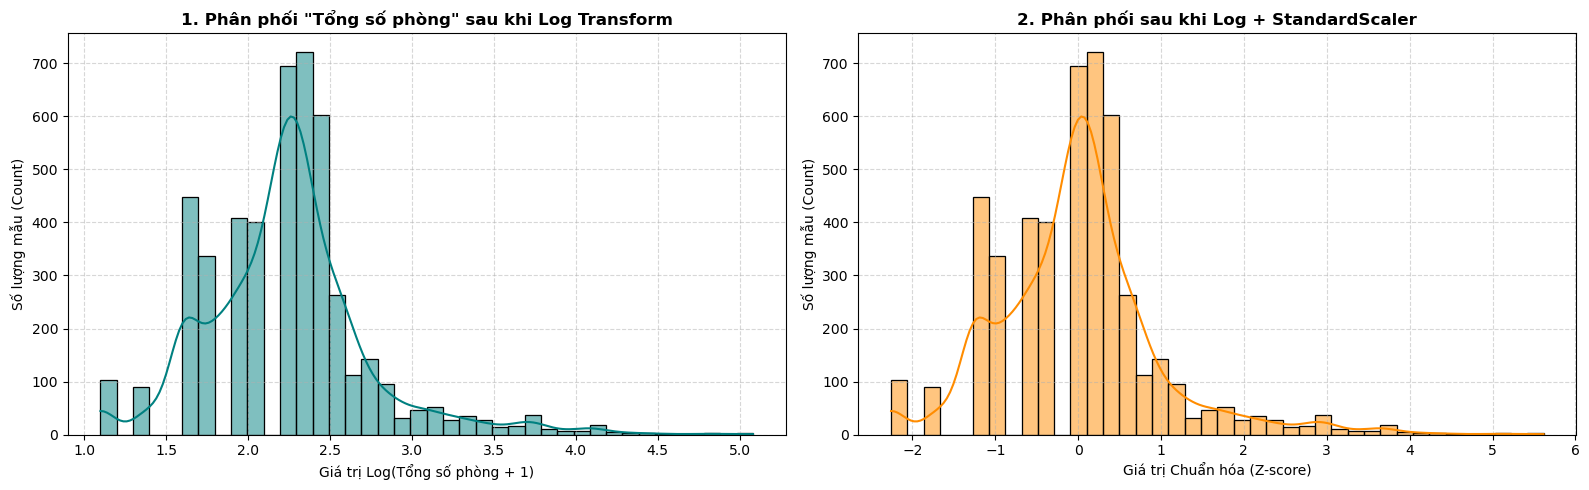

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Tong_so_phong_test = X_train['Tổng số phòng'].copy()

Tong_so_phong_log = np.log1p(Tong_so_phong_test)

scaler_test = StandardScaler()
Tong_so_phong_scaled = scaler_test.fit_transform(Tong_so_phong_log.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(Tong_so_phong_log, kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title('1. Phân phối "Tổng số phòng" sau khi Log Transform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị Log(Tổng số phòng + 1)')
axes[0].set_ylabel('Số lượng mẫu (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(Tong_so_phong_scaled, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('2. Phân phối sau khi Log + StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Chuẩn hóa (Z-score)')
axes[1].set_ylabel('Số lượng mẫu (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Method 2: RobustScaler

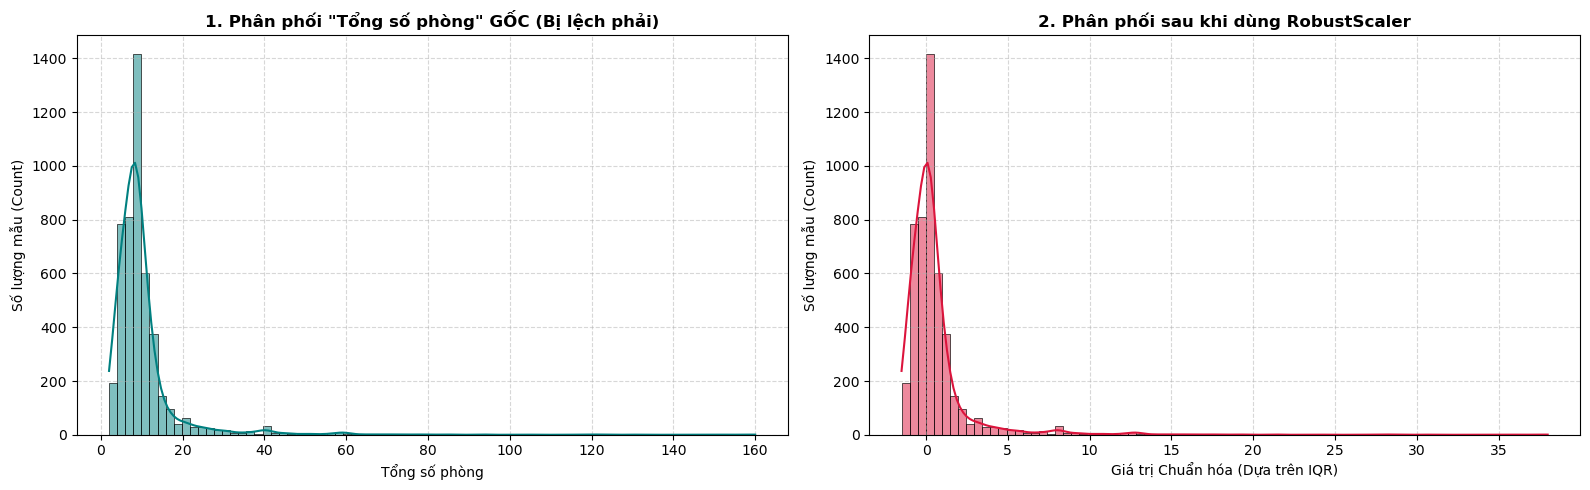

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

Tong_so_phong_test = X_train['Tổng số phòng'].copy()

scaler_robust_test = RobustScaler()
Tong_so_phong_robust = scaler_robust_test.fit_transform(Tong_so_phong_test.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(Tong_so_phong_test, kde=True, ax=axes[0], color='teal', bins=80)
axes[0].set_title('1. ORIGINAL "Total Rooms" Distribution (Shifted Right)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total number of rooms')
axes[0].set_ylabel('Number of samples (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(Tong_so_phong_robust, kde=True, ax=axes[1], color='crimson', bins=80)
axes[1].set_title('2. Distribution after using RobustScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value after normalization (Based on IQR)')
axes[1].set_ylabel('Number of samples (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Choose a Method

🚀 Đang áp dụng Phương pháp 1: Logarithm + StandardScaler...
✅ Hoàn tất áp dụng Log + StandardScaler cho cả X_train và X_test!


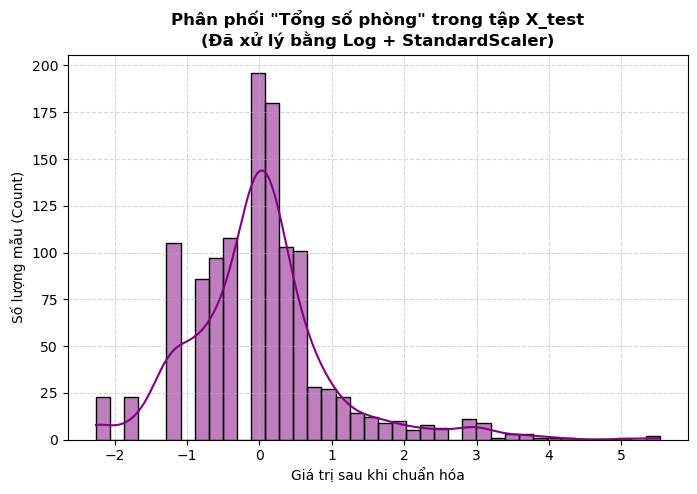

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler


PHUONG_PHAP = 1 

if PHUONG_PHAP == 1:
    print("Applying Method 1: Logarithm + StandardScaler...")
    X_train['Tổng số phòng'] = np.log1p(X_train['Tổng số phòng'])
    X_test['Tổng số phòng'] = np.log1p(X_test['Tổng số phòng'])
    
    scaler = StandardScaler()
    X_train['Tổng số phòng'] = scaler.fit_transform(X_train[['Tổng số phòng']])
    X_test['Tổng số phòng'] = scaler.transform(X_test[['Tổng số phòng']])
    method_name = "Log + StandardScaler"

elif PHUONG_PHAP == 2:
    print("Applying Method 2: RobustScaler...")
    scaler = RobustScaler()
    X_train['Tổng số phòng'] = scaler.fit_transform(X_train[['Tổng số phòng']])
    X_test['Tổng số phòng'] = scaler.transform(X_test[['Tổng số phòng']])
    method_name = "RobustScaler"

else:
   print(" Invalid selection. Please select 1 or 2.")

if PHUONG_PHAP in [1, 2]:
    print(f" Finished applying {method_name} to both X_train and X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Tổng số phòng'], kde=True, color='purple', bins=40)
    plt.title(f'Distribution of "Total number of rooms" in X_test\n(Processed with {method_name})', fontsize=12, fontweight='bold')
    plt.xlabel('Value after normalization')
    plt.ylabel('Number of samples (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 3.4 Normalize 'Number of Floors'

The 'Number of Floors' feature has 2 peaks. It has a relatively small range of values (mainly from 1 to 6 floors, maximum 14 floors). You can use MinMaxScaler to bring everything into a fixed range [0, 1]. This method preserves the linear proportional distance between floors without distortion by mean values.

### Method 1: Use StandardScaler

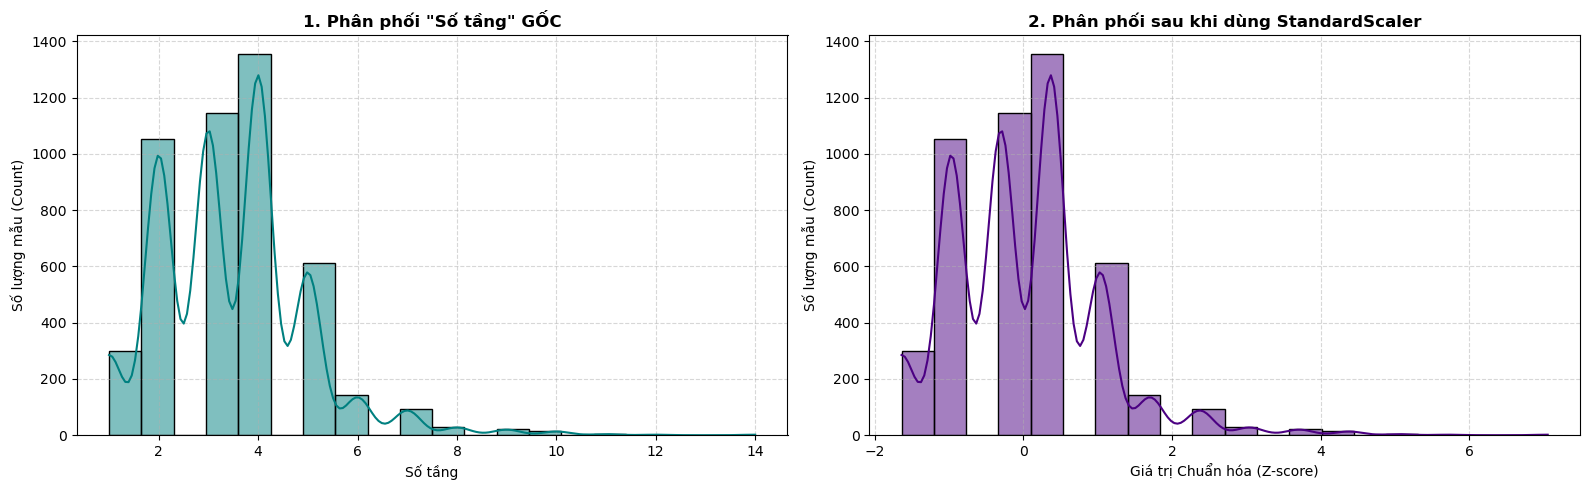

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

so_tang_test = X_train['Số tầng'].copy()

scaler_std_test = StandardScaler()
so_tang_std = scaler_std_test.fit_transform(so_tang_test.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(so_tang_test, kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('1. ORIGINAL "Number of Floors" Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of floors')
axes[0].set_ylabel('Number of samples (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(so_tang_std, kde=True, ax=axes[1], color='indigo', bins=20)
axes[1].set_title('2. Distribution after using StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Normalized Value (Z-score)')
axes[1].set_ylabel('Number of samples (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Method 2: Use MinMaxScaler

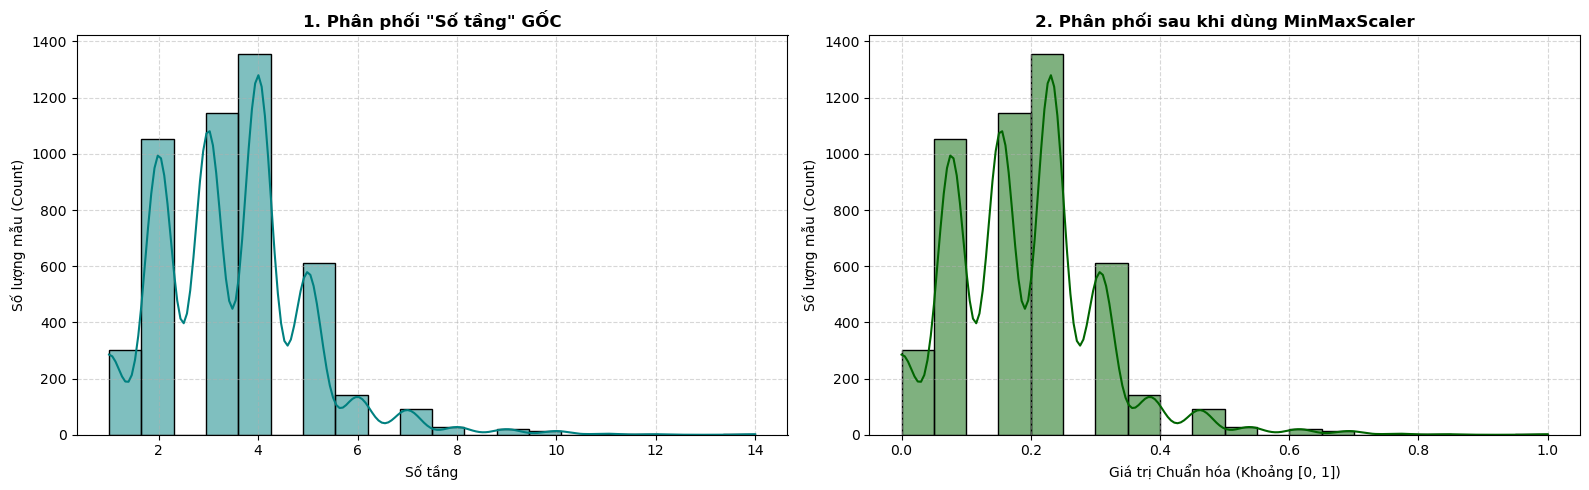

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

so_tang_test = X_train['Số tầng'].copy()

scaler_minmax_test = MinMaxScaler()
so_tang_minmax = scaler_minmax_test.fit_transform(so_tang_test.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(so_tang_test, kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('1. ORIGINAL "Number of Floors" Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of floors')
axes[0].set_ylabel('Number of samples (Count)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(so_tang_minmax, kde=True, ax=axes[1], color='darkgreen', bins=20)
axes[1].set_title('2. Distribution after applying MinMaxScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value after MinMax Scaling (Range [0, 1])')
axes[1].set_ylabel('Number of samples (Count)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Select method


The common feature of both methods is that they do not change the shape of the original distribution

🚀 Đang áp dụng chính thức: MinMaxScaler lên cột Số tầng...
✅ Hoàn tất áp dụng MinMaxScaler cho cả X_train và X_test!


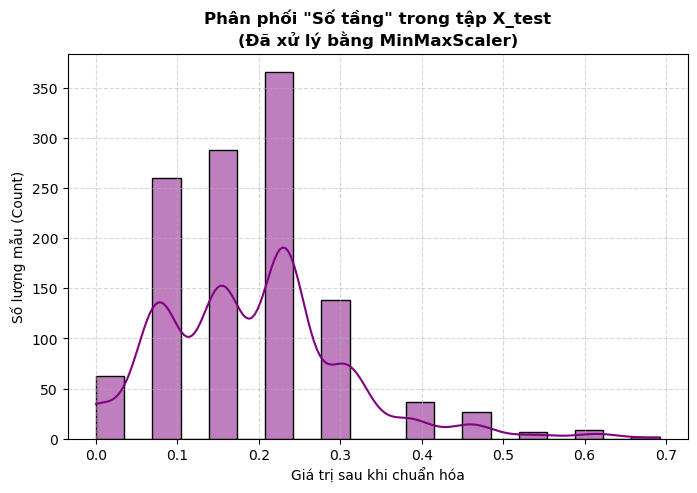

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

CHON_PHUONG_PHAP = 2 
if CHON_PHUONG_PHAP == 1:
    print(" Officially applying: StandardScaler to the Number of Floors column...")
    scaler_tang = StandardScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "StandardScaler"

elif CHON_PHUONG_PHAP == 2:
    print(" Officially applying: MinMaxScaler to the Number of Floors column...")
    scaler_tang = MinMaxScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "MinMaxScaler"

else:
   print("Invalid selection. Please only select number 1 or 2.")


if CHON_PHUONG_PHAP in [1, 2]:
    print(f"Hoàn tất áp dụng {method_title} cho cả X_train và X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Số tầng'], kde=True, color='purple', bins=20)
    plt.title(f'Phân phối "Số tầng" trong tập X_test\n(Đã xử lý bằng {method_title})', fontsize=12, fontweight='bold')
    plt.xlabel('Giá trị sau khi chuẩn hóa')
    plt.ylabel('Số lượng mẫu (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

🚀 Đang áp dụng chính thức: MinMaxScaler lên cột Số tầng...
✅ Hoàn tất áp dụng MinMaxScaler cho cả X_train và X_test!


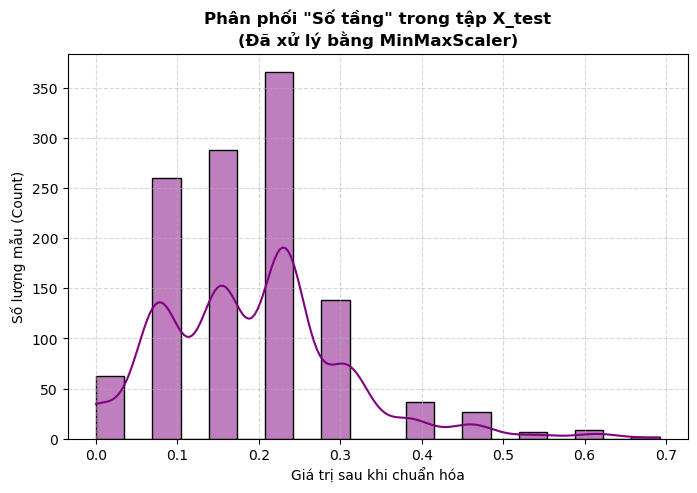

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

CHON_PHUONG_PHAP = 2 
if CHON_PHUONG_PHAP == 1:
    print("🚀 Officially applying: StandardScaler to the Number of Floors column...")
    scaler_tang = StandardScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "StandardScaler"

elif CHON_PHUONG_PHAP == 2:
    print("🚀 Officially applying: MinMaxScaler to the Number of Floors column...")
    scaler_tang = MinMaxScaler()
    X_train['Số tầng'] = scaler_tang.fit_transform(X_train[['Số tầng']])
    X_test['Số tầng'] = scaler_tang.transform(X_test[['Số tầng']])
    method_title = "MinMaxScaler"

else:
    print("Invalid selection. Please only select number 1 or 2.")

if CHON_PHUONG_PHAP in [1, 2]:
    print(f" Finished applying {method_title} to both X_train and X_test!")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(X_test['Số tầng'], kde=True, color='purple', bins=20)
    plt.title(f'Distribution "Number of floors" in X_test\n(Processed with {method_title})', fontsize=12, fontweight='bold')
    plt.xlabel('Value after normalization')
    plt.ylabel('Number of samples (Count)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

## 2.5 Chuẩn hoá biến mục tiêu bằng Log Transform

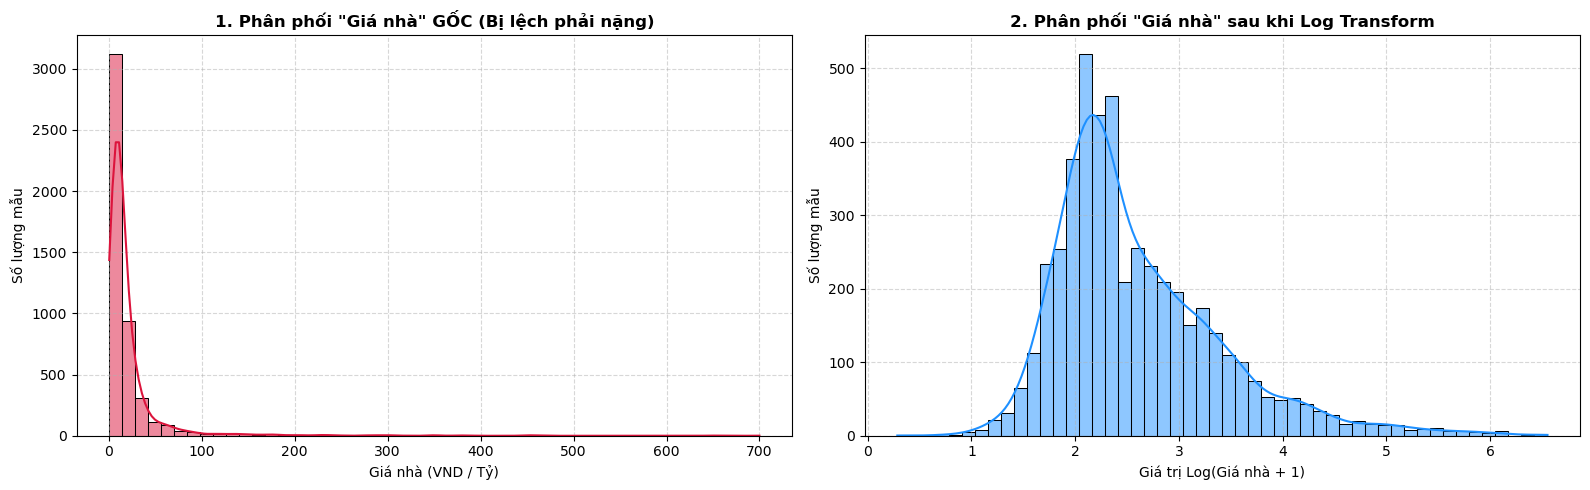

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_train_log = np.log1p(y_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(y_train, kde=True, ax=axes[0], color='crimson', bins=50)
axes[0].set_title('1. Phân phối "Giá nhà" GỐC (Bị lệch phải nặng)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá nhà (VND / Tỷ)') 
axes[0].set_ylabel('Số lượng mẫu')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(y_train_log, kde=True, ax=axes[1], color='dodgerblue', bins=50)
axes[1].set_title('2. Phân phối "Giá nhà" sau khi Log Transform', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị Log(Giá nhà + 1)')
axes[1].set_ylabel('Số lượng mẫu')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

When evaluated, y_pred will be in log form. Before calculating the measurement, it must be converted back to the real value.

In [ ]:
import numpy as np

y_train_log = np.log1p(y_train)
if 'y_test' in locals():
    y_test_log = np.log1p(y_test)

X_train_linear = X_train.copy()
X_test_linear = X_test.copy()

df_train_linear = pd.concat([X_train_linear, y_train_log], axis=1)
if 'y_test' in locals():
    df_test_linear = pd.concat([X_test_linear, y_test_log], axis=1)
else:
    df_test_linear = X_test_linear.copy()

df_train_linear.to_csv('data_output/3_data_preprocessed_linear_train.csv', index=False)
df_test_linear.to_csv('data_output/3_data_preprocessed_linear_test.csv', index=False)

print("💾FILE 3: Completed normalized data saved for Linear model successfully!")
print(" (Note: The target variable 'y' in this file has been converted to Log1p)")
print("   -> data_output/3_data_preprocessed_linear_train.csv")
print("   -> data_output/3_data_preprocessed_linear_test.csv")

💾 FILE 3: Đã lưu dữ liệu chuẩn hóa hoàn chỉnh cho mô hình Tuyến tính thành công!
   (Lưu ý: Biến mục tiêu 'y' trong file này đã được chuyển đổi sang Log1p)
   -> data_output/3_data_preprocessed_linear_train.csv
   -> data_output/3_data_preprocessed_linear_test.csv
